<a href="https://colab.research.google.com/github/Mil-333/optimization-methods/blob/main/lab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Քայլ  | a        | b        | b-a      | x1       | x2      
-----------------------------------------------------------------
1     | 0.0000   | 3.0000   | 3.0000   | 1.375    | 1.625   
2     | 0.0000   | 1.6250   | 1.6250   | 0.688    | 0.938   
3     | 0.6875   | 1.6250   | 0.9375   | 1.031    | 1.281   
4     | 1.0312   | 1.6250   | 0.5938   | 1.203    | 1.453   
5     | 1.0312   | 1.4531   | 0.4219   | -        | -       
-----------------------------------------------------------------
Ալգորիթմն ավարտվեց: x ≈ 1.2422


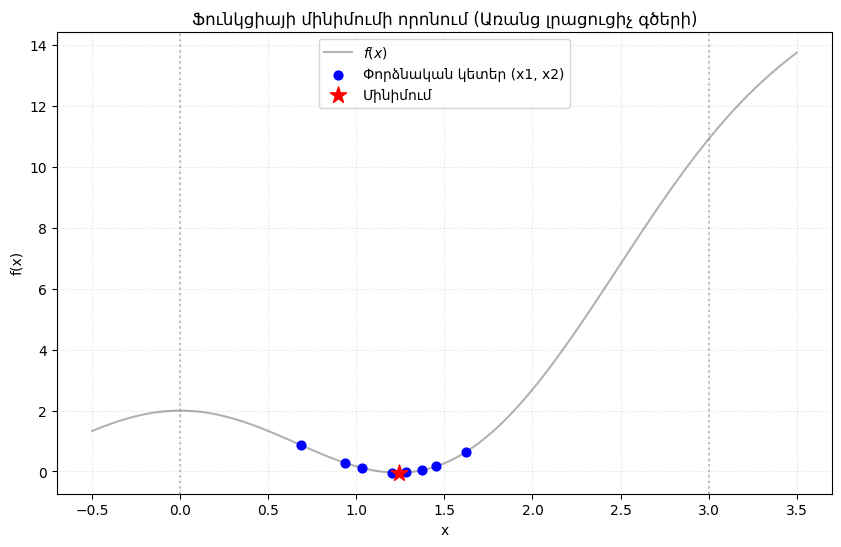

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Ֆունկցիայի սահմանում f(x) = x^2 + 2*cos(2x)
def f(x):
    return x**2 + 2 * np.cos(2 * x)

# 2. Տվյալների սահմանում
a, b = 0, 3
epsilon = 0.5
delta = 0.125

history_points_x = []
history_points_y = []
curr_a, curr_b = a, b
step = 0

# Աղյուսակի գլխամասը
print(f"{'Քայլ':<5} | {'a':<8} | {'b':<8} | {'b-a':<8} | {'x1':<8} | {'x2':<8}")
print("-" * 65)

# 3. Մինիմումի որոնում (Dichotomy)
while (curr_b - curr_a) >= epsilon:
    step += 1
    center = (curr_a + curr_b) / 2
    x1 = center - delta
    x2 = center + delta

    f1, f2 = f(x1), f(x2)

    # Պահում ենք կետերը գրաֆիկի համար
    history_points_x.extend([x1, x2])
    history_points_y.extend([f1, f2])

    # Տպում ենք ընթացիկ քայլը
    print(f"{step:<5} | {curr_a:<8.4f} | {curr_b:<8.4f} | {curr_b - curr_a:<8.4f} | {x1:<8.3f} | {x2:<8.3f}")

    if f1 < f2:
        curr_b = x2
    else:
        curr_a = x1

# 4. Ավելացնում ենք վերջնական (5-րդ) տողը աղյուսակում
step += 1
print(f"{step:<5} | {curr_a:<8.4f} | {curr_b:<8.4f} | {curr_b - curr_a:<8.4f} | {'-':<8} | {'-':<8}")

x_min_final = (curr_a + curr_b) / 2
print("-" * 65)
print(f"Ալգորիթմն ավարտվեց: x ≈ {x_min_final:.4f}")

# 5. Գրաֆիկական պատկերում
x_plot = np.linspace(-0.5, 3.5, 1000)
y_plot = f(x_plot)

plt.figure(figsize=(10, 6))
plt.plot(x_plot, y_plot, color='black', alpha=0.3, label='$f(x)$')

# Ցույց ենք տալիս բոլոր x1, x2 կետերը, որոնք մասնակցել են հաշվարկին
plt.scatter(history_points_x, history_points_y, color='blue', s=40, label='Փորձնական կետեր (x1, x2)', zorder=5)

# Նշում ենք սկզբնական հատվածի սահմանները
plt.axvline(x=0, color='gray', linestyle=':', alpha=0.5)
plt.axvline(x=3, color='gray', linestyle=':', alpha=0.5)

# Վերջնական մինիմումի կետը
plt.scatter(x_min_final, f(x_min_final), color='red', s=150, marker='*', label='Մինիմում', zorder=10)

plt.title('Ֆունկցիայի մինիմումի որոնում (Առանց լրացուցիչ գծերի)')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.4)
plt.show()
